# **Classification Course**


---

In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to classification problems***. We will use **"decision tree" model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***. The goal is to practice the knowledge required for each step depending on the level.


#Level 0（☆☆☆）


---


In Level 0, you will learn about decision trees. You will also learn about data characteristics and basic preprocessing methods.

##0.1. Decision Tree

A **decision tree** is a method that learns the relationship between features and labels by repeatedly splitting the data using if-then rules based on the values of the features. It’s mainly used for **classification tasks**, where the goal is to predict categories, but it can also be applied to regression tasks, where the goal is to predict numbers.

When used for classification, it is called a classification tree; when used for regression, it is called a regression tree. In this course, we’ll be using the decision tree as a classification tree.

Suppose we have a dataset containing information about poisonous mushrooms. If the goal is to tell whether a mushroom is poisonous or not based on its appearance, then the column indicating whether it is poisonous (Yes or No) would serve as the label. The columns with information like the height or width of the stem would be considered features.

The ID column, on the other hand, is simply a random identifier that has no relationship to whether the mushroom is poisonous. Therefore, it is not considered a feature.

| ID  | height(cm) | width(cm)|poison(Yes/No)|
|-----|----------|----------|---|
| 001 | 5        | 4        |N |
| 002 | 3        | 2        |N|
| 003 | 6        | 2        |Y|
| 004 | 2        | 1        |N|
| 005 | 5        | 1        |Y|

If we split the table above based on whether the feature `height` is 4cm or less, the result would look like this:

**[Mushrooms with height ≤ 4 cm] ⇒ Group 1 (all non-poisonous)**

| ID  | height | width|poison|
|-----|----------|----------|---|
| 002 | 3        | 2        |N|
| 004 | 2        | 1        |N|

**[Mushrooms with height > 4 cm] ⇒ Group 2 (includes both poisonous and non-poisonous)**

| ID  | height| width|poison|
|-----|----------|----------|---|
| 001 | 5        | 4        |N |
| 003 | 6        | 2        |Y|
| 005 | 5        | 1        |Y|

As a result, we can classify mushrooms with height ≤ 4 cm as non-poisonous.
However, among mushrooms with height greater than 4 cm, both poisonous and non-poisonous mushrooms are mixed.
So, next, let’s split the mushrooms in that group based on whether their width is 3cm or less.

**[Mushrooms with height > 4 cm and width ≤ 3 cm] ⇒ Group 2–1 (all poisonous)**

| ID  | height | width|poison|
|-----|----------|----------|---|
| 003 | 6        | 2        |Y|
| 005 | 5        | 1        |Y|

**[Mushrooms with height > 4 cm and width > 3 cm] ⇒ Group 2–2 (all non-poisonous)**

| ID  | height | width|poison|
|-----|----------|----------|---|
| 001 | 5        | 4        |N|

By repeatedly applying conditional splits, we can classify mushrooms into poisonous and non-poisonous groups.

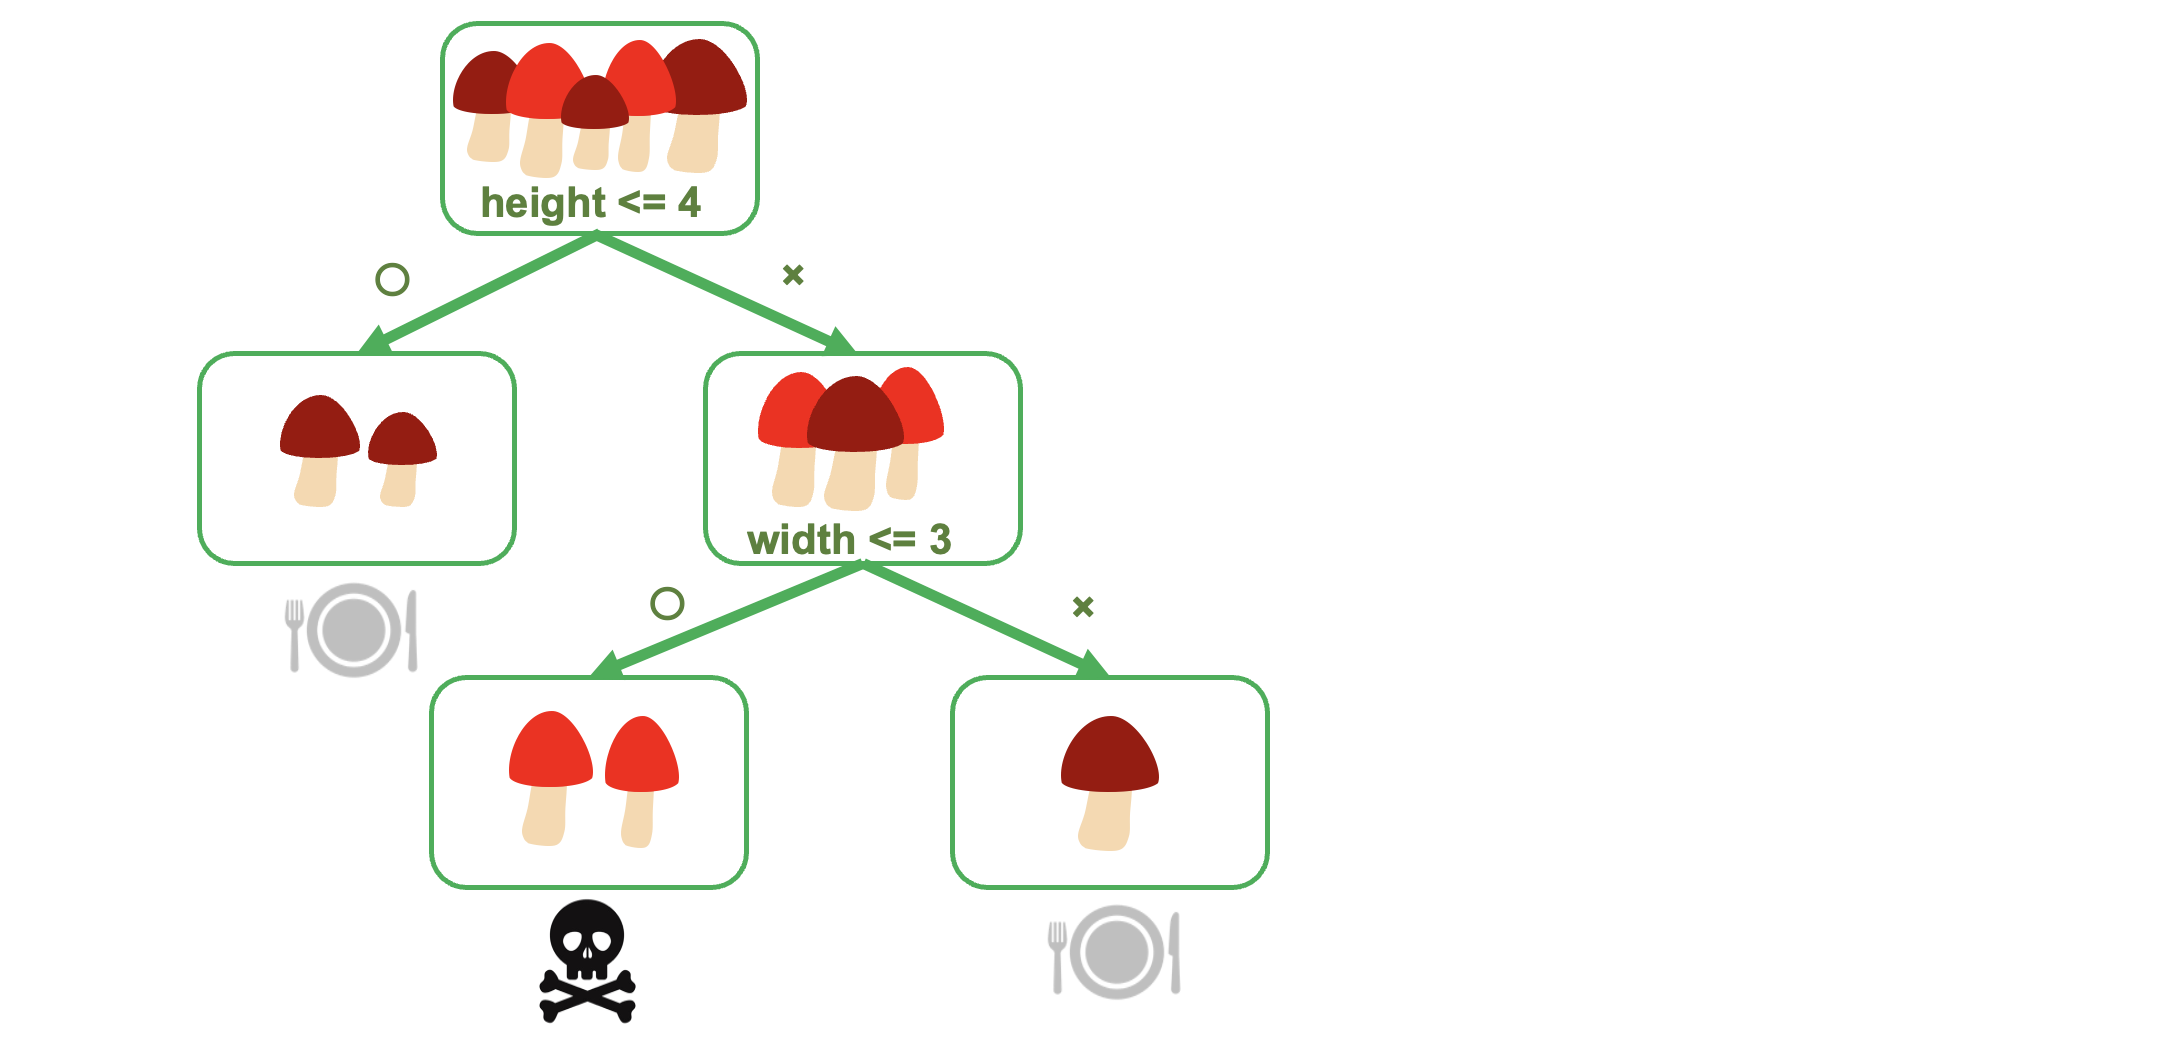


By using the splitting conditions we just created, we can predict whether a mushroom is poisonous —even for a new data point we haven't seen before.

For example, let’s say we have a mushroom with a stem height of 5 cm and a stem width of 2 cm.
Based on the conditions we defined earlier, we can predict that it falls into Group 2–1, which means it is poisonous.

With this small number of examples, we can manually examine the data and determine how to split it.
But once the data grows to 1,000, 10,000, or even 100,000 points—and if the number of features increases as well—it becomes extremely difficult to do this by hand. The decision tree is a method that automatically learns these splitting conditions from the data.

##0.2. Understanding the Data


Let’s explore the different types of data that are important for understanding a dataset.
In the table we saw earlier, we referred to information such as height and width as features.
Features can be classified into **quantitative data** and **qualitative data**.

**Quantitative data** is numerical and expresses information such as height or width on a continuous scale. **Qualitative data**, on the other hand, includes attributes such as whether the stem is tall or short, or their odor, and represents categories. These categories are not always binary — for example, mushroom odor or color may fall into three or more categories.

Here’s an example of a mushroom dataset that contains qualitative features:

| ID  | bruises | odor |poison|
|-----|------|------|--|
| 001 | Y | N   |N|
| 002 | N | Y   |N|
| 003 | Y | Y   |Y|
| 004 | N | Y   |N|

Even with this kind of data, we can still create conditional splits based on things like whether the mushroom has bruises or odor.

However, computers determine the splitting conditions by evaluating whether a feature is greater than or equal to a certain number.
This means that qualitative text data must be preprocessed and converted into a numerical format that the computer can interpret.

A common approach is **dummy variable encoding**, where each category is turned into a 0/1 indicator.

For example, if we convert the presence or absence of bruises and odor into 1s and 0s, the dataset we just saw would look like this:


| ID  | bruises | odor |poison|
|-----|------|------|--|
| 001 | 1 | 0   |N|
| 002 | 0 | 1   |N|
| 003 | 1 | 1   |Y|
| 004 | 0 | 1   |N|


Thanks to dummy variable encoding, qualitative data can be transformed into a numerical format and treated similarly to quantitative data.

This means the computer can now determine classification rules based on criteria such as whether the value for bruises or odor is 0.5 or more, just as it would for numerical features.

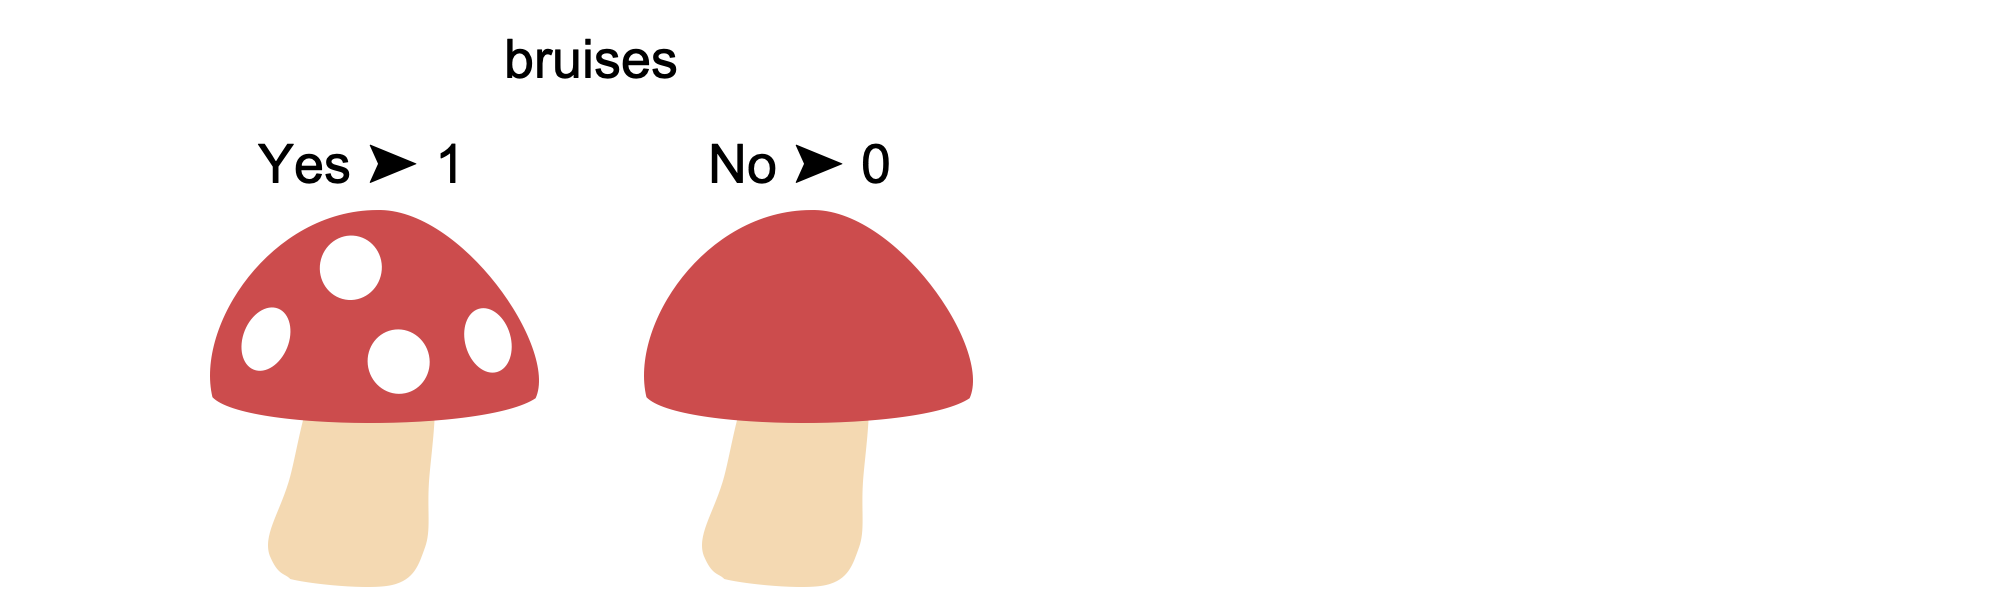

##0.3. Processing Data

To perform data preprocessing and build machine learning models like this, there are **libraries** such as pandas and scikit-learn, which allow for easy implementation. Therefore, as long as you can write minimal code yourself, you can work with data without much difficulty.

In a code cell, you can you can import a library by writing, `import (library name)`.

Next, let’s import the **pandas** library, which is used to manage tabular data.
Just enter the following code into a code cell to import pandas.
In Python, it is common to give an alias name when importing a library so that it can be used efficiently.
For pandas, the alias `pd` is commonly used.

To use functions in the pandas library, it is necessary to prefix them with the alias `pd`.

Let’s run the following code in a code cell:
Click the code cell and press the play button on the left to execute it (see the figure below).

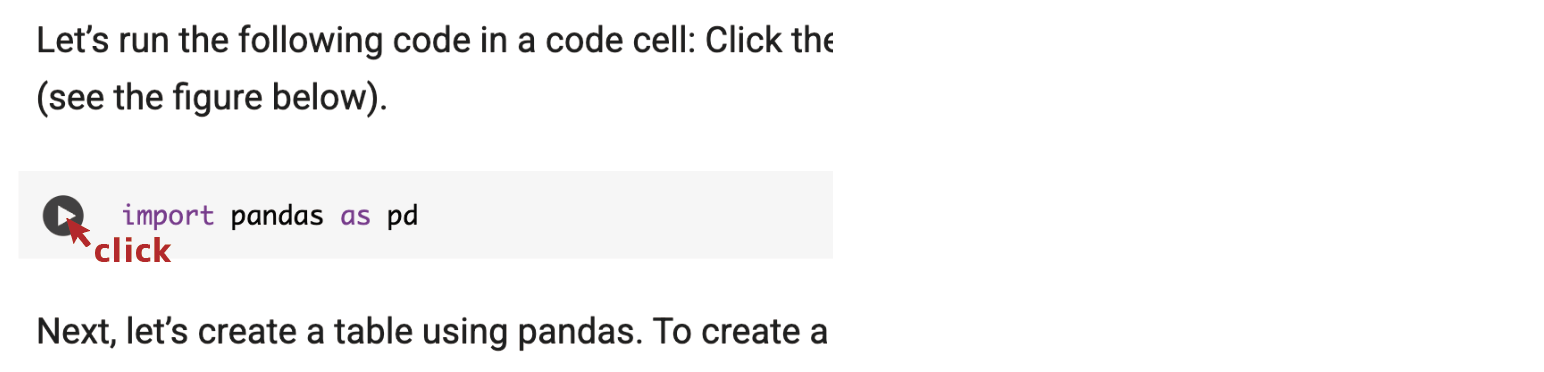

In [ ]:
import pandas as pd

Next, let’s create a table using pandas.
To create a table, you use the `pandas.DataFrame` class.

When using a class from a library, you always need to write it like `pd.ClassName`.
To create an object from a class—called **instantiation**—you write the class name followed by parentheses. Inside the parentheses, you provide the required values, known as arguments.

To create a DataFrame instance, you pass either a 2D list or a dictionary where the keys are column names and the values are data.
For strings, be careful not to forget to enclose them in single or double quotes.

We’ll create the qualitative features from the table we saw earlier and practice dummy variable encoding.

>**[Creating a Table in pandas]**
>
>```Python
>variable_name = pd.DataFrame(2D list)
>```



In [ ]:
df = pd.DataFrame([['Y', 'N'],['N','Y'],['Y', 'Y'], ['N', 'Y']])
df

,0,1
0,Y,N
1,N,Y
2,Y,Y
3,N,Y


In a DataFrame, data is managed in rows and columns.
The row numbers on the left side (vertical direction) are called the **indices**, and the names of the **columns** at the top (horizontal direction) are called columns.
By default, the index starts at 0, and there are no column names set unless explicitly defined.

So, unlike the tables we’ve seen so far, if you create a DataFrame with only data, the top row will not show any column names.

You can assign column names to an existing DataFrame by using the columns attribute and providing a list of new column names like ['column1', 'column2'].
You can also assign column names when creating a DataFrame by specifying a list with the columns argument.

Make sure each column name is written as a string enclosed in single quotes.

In [ ]:
df = pd.DataFrame([['Y', 'N'],['N','Y'],['Y', 'Y'], ['N', 'Y']], columns=['bruises', 'odor'])
df

,bruises,odor
0,Y,N
1,N,Y
2,Y,Y
3,N,Y


Now we’ve got our data ready about whether the mushrooms have bruises or an odor.
Since the values are written as Yes and No, let’s apply the dummy variable conversion we discussed earlier.


To do this, we use the `get_dummies()` function from pandas.
When you pass your DataFrame into the parentheses of `get_dummies()` like this:

```
pd.get_dummies(DataFrame)
```

it converts categorical values into dummy variables and returns the transformed DataFrame.



In [ ]:
df2 = pd.get_dummies(df)
df2

,bruises_N,bruises_Y,odor_N,odor_Y
0,False,True,True,False
1,True,False,False,True
2,False,True,False,True
3,True,False,False,True


As a result, our DataFrame now contains four columns. Instead of numeric values like 0 and 1, the data is represented using boolean values (True and False).

This happened because the function creates one column for “Is it Yes?” and another for “Is it No?”, assigning boolean value (True or False) accordingly. However, since True for Yes and False for No convey the same information, this setup is redundant.

To avoid this kind of duplication, we can use the `drop_first` option in the `get_dummies()` function.
By passing `drop_first = True`, the function removes the first category—usually “No”—to eliminate duplicate information.

Even though the values remain as a boolean value (True and False), they are internally treated as 1 and 0, so they can still be used for analysis. If you want to explicitly convert them to integers, you can pass `dtype = int`. This will convert True to 1 and False to 0.

In [ ]:
df2 = pd.get_dummies(df, drop_first = True, dtype = int)
df2

,bruises_Y,odor_Y
0,1,0
1,0,1
2,1,1
3,0,1


Now, the column values are set to 1 for “Yes” and 0 for “No,” just as intended. However, the column names were changed during the process, so let’s update them.

To rename the columns of an existing DataFrame, use the `.columns` attribute. By assigning a list of new column names to it, the column names will be updated accordingly.

In [ ]:
df2.columns = ['bruises', 'odor']
df2

,bruises,odor
0,1,0
1,0,1
2,1,1
3,0,1


To save your table data as a CSV file, use `to_csv()` method of a DataFrame. **CSV stands for Comma-Separated Values** and uses line breaks to indicate new rows.

For the data above, the CSV file would look like this:


```
bruises,odor
1,0
0,1
1,1
0,1
```


By running the code below, it will save the DataFrame as a file named `Mushroom_Appearence_Data.csv`. Passing `index = False` will save the CSV file without the index numbers.

In [ ]:
df2.to_csv('Mushroom_Appearence_Data.csv', index = False)

When you run the code above, the CSV file will be saved.

Click the 📁 file icon on the left panel of Google Colaboratory and confirm that `Mushroom_Appearence_Data.csv` has been saved (see the image below). Right-click the file to download it to your local environment.

You can later open the CSV file in Excel or other spreadsheet software.

You can also open `Mushroom_Appearence_Data.csv` directly within Google Colaboratory. Double-clicking the file will display its contents on the right side of the screen, allowing you to view the data.

You can also reload the saved file as a DataFrame using pandas’s `read_csv()` function and assign it to a variable.

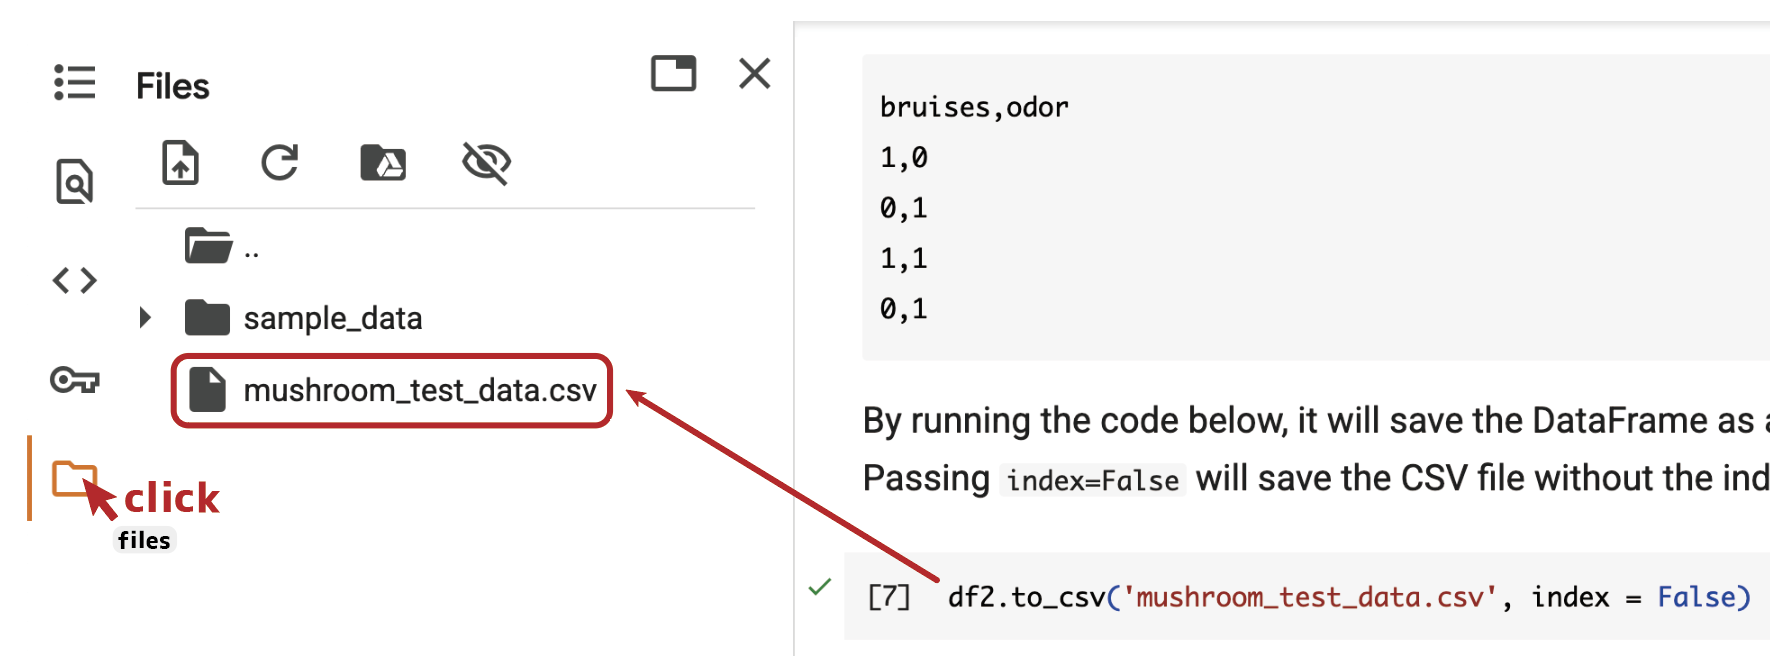

In [ ]:
df3 = pd.read_csv('Mushroom_Appearence_Data.csv')
df3

,bruises,odor
0,1,0
1,0,1
2,1,1
3,0,1


##0.4. Model Building and Evaluation

To build a machine learning model, you will import the **scikit-learn** machine learning library.
The import method is the same as when using pandas.
scikit-learn offers various types of models, but you only need to import the model you want to use.

When importing scikit-learn, one thing to note is that the library is called ***sklearn*** in the code.

We will use DecisionTreeClassifier, the class for decision tree classification models, from the tree module of sklearn.

Here’s how to import it:

>**[Importing the DecisionTreeClassifier class from scikit-learn's tree module]**
>
>```Python
>from sklearn.tree import DecisionTreeClassifier
>```

By using `from ... import ...`, you can specify and import only the class you need, allowing you to use it directly without prefixing it with a module name.

To create a model, simply write the class name followed by parentheses and assign it to a variable. This process is called instantiating the model.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

With just these two lines, you have created a decision tree model for classification tasks.
All that remains is to train the model with data, and the prediction model will be complete.

Next, we will use the poisonous mushroom data introduced earlier.
Run the code below to create the same data.



In [ ]:
import pandas as pd
test_data = pd.DataFrame([[5,4,'N'],[3,2,'N'],[6,2,'Y'],[2,1,'N'],[5,1,'Y']], columns = ['height', 'width','poison'])
test_data

,height,width,poison
0,5,4,N
1,3,2,N
2,6,2,Y
3,2,1,N
4,5,1,Y


Now, let’s separate the features and labels from the table to train the model. To extract specific columns from a DataFrame, use the following syntax: `variable_name[['column1', 'column2']]`.

Note that the column names must be provided as a list of strings within square brackets [].

In [ ]:
x = test_data[['height', 'width']]
x

,height,width
0,5,4
1,3,2
2,6,2
3,2,1
4,5,1


Similarly, to extract the label column, use a single pair of square brackets without enclosing the column name in a list.

In [ ]:
t = test_data['poison']
t

,poison
0,N
1,N
2,Y
3,N
4,Y


When specifying only one column, the returned object is not a DataFrame but a Series class object. A Series is also a class in Pandas that manages values collectively. While a DataFrame manages tabular data consisting of rows and columns (index and columns), a Series manages data with only one column, using the index for the rows. The index is assigned as a consecutive number starting from 0, just like in a DataFrame. You can check each class by running the following code.

In [ ]:
print(type(x))
print(type(t))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


If you want to extract a single column as a DataFrame instead of a Series, enclose the column name in a list using square brackets ([]) containing one element.



In [ ]:
print(type(test_data[['poison']]))

<class 'pandas.core.frame.DataFrame'>


Now, let’s pass the feature variables `x` and labels `t` to the model and train it. In scikit-learn, the `fit()` method is used to train a machine learning model.

In [ ]:
model.fit(x,t)

DecisionTreeClassifier()

Training is completed in a single line. To check how well the model performs, you can use the `score()` method.

In [ ]:
model.score(x,t)

1.0

If 1.0 is displayed, it indicates 100% accuracy, meaning the training was successful. However, this alone does not show how the decision tree makes decisions, so let’s examine the tree’s splitting criteria.

The `plot_tree()` function, found in the tree module of sklearn, provides a visual representation of the decision tree's splitting rules. As with the decision tree class, import only the `plot_tree()` function. Pass the model as an argument and the column names to the `feature_names` parameter to visualize the tree structure.

[Text(0.4, 0.8333333333333334, 'height <= 4.0\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'width <= 3.0\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

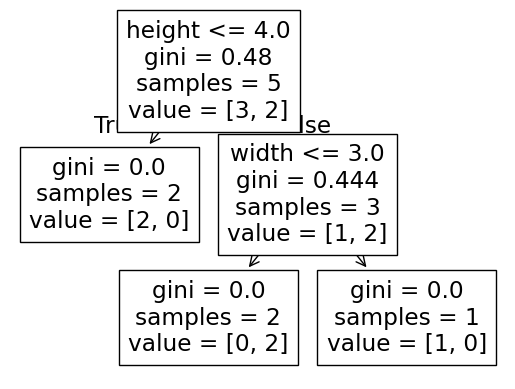

In [ ]:
from sklearn.tree import plot_tree
plot_tree(model, feature_names = x.columns)

From the diagram, you can see that the height column is first split at 4 or less, followed by a split in the width column at 3 or less. The label “samples” indicates the number of data points. You can observe that the 5 data points are first divided into groups of 2 and 3, which are then further split into 2 and 1. This corresponds to the result shown in the earlier decision tree example.

That concludes the supervised learning workflow for classification problems. By using the library scikit-learn, you can construct a machine learning prediction model in just three lines of code:

* Import the machine learning library → `from ... import ...`
* Create an instance of the model → `model = DecisionTreeClassifier()`
* Fit the model to the data → `model.fit()`

This is the end of the Level 0 content. To wrap up, let’s try the following practical exercises as a review.

##0.5. Practice Problems

In Level 0, you learned about data features, preprocessing methods, and decision trees. Based on the content of Level 0, please try solving the following practice problems. For answers and explanations, please refer to the video.

**Q0-1.** Create the following table as a pandas DataFrame.

|  | bruises | odor |poison|
|-----|------|------|--|
| 0 | Y | N   |N|
| 1 | N | Y   |Y|

**Q0-2.** Convert the DataFrame you created in Question 0-1 into dummy variables so that it becomes like the table below.

|   | bruises | odor |poison|
|-----|------|------|--|
| 0 | 1 | 0   |0|
| 1 | 0 | 1   |1|

**Q0-3.** Save the above table as a CSV file with an appropriate file name (e.g., data.csv). Make sure the file has been saved. Note: Use single quotes when writing string values.